# Mutual Fund Analytics Platform

## Objective
Briefly explain the purpose of the notebook `05_advanced_analytics.ipynb`.

## Author
Bhawani Meena

## Tools Used
List the major libraries used in this notebook.


# Mutual Fund Analysis Notebook

This notebook performs various advanced analytics on mutual fund data, including risk assessment, investor behavior analysis, and portfolio diversification. It covers the following key areas:

1.  **Data Loading and Preprocessing**: Initial setup and loading of necessary datasets.
2.  **Downside Risk Analysis (VaR & CVaR)**: Calculation of Value at Risk and Conditional Value at Risk.
3.  **Risk-Adjusted Performance Trends (Rolling Sharpe Ratio)**: Analysis of fund performance adjusted for risk over time.
4.  **Investor Cohort Analysis**: Grouping investors by their first transaction year to understand behavioral patterns.
5.  **SIP Continuity Analysis**: Evaluating the regularity of Systematic Investment Plans (SIPs).
6.  **Portfolio Diversification and Sector Concentration (HHI)**: Assessing portfolio concentration using the Herfindahl-Hirschman Index.
7.  **Fund Recommendation**: Providing fund recommendations based on investor risk appetite.

## Setup: Mount Google Drive

This cell mounts your Google Drive to access data files stored in your `/content/drive/MyDrive/bluestock_mf_capstone/data/` directory.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Downside Risk Analysis (VaR & CVaR)

This section loads Net Asset Value (NAV) data, calculates daily returns, and then computes 95% Historical Value at Risk (VaR) and Conditional Value at Risk (CVaR) for each mutual fund. These metrics help quantify the potential downside risk of investments. The results are then merged with fund master details and saved as a CSV report.

## Data Loading

In [3]:
import pandas as pd
import numpy as np

# -------------------------
# Load NAV Data
# -------------------------

nav = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/clean_nav.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

# -------------------------
# Daily Returns
# -------------------------

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

# -------------------------
# Fund Master
# -------------------------

fund = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/raw/01_fund_master.csv"
)

# -------------------------
# VaR & CVaR Calculation
# -------------------------

results = []

for code, group in nav.groupby("amfi_code"):

    returns = (
        group["daily_return"]
        .dropna()
    )

    if len(returns) > 0:

        # 95% Historical VaR
        var_95 = np.percentile(
            returns,
            5
        )

        # CVaR
        cvar_95 = (
            returns[
                returns <= var_95
            ]
            .mean()
        )

        results.append([
            code,
            round(var_95 * 100, 4),
            round(cvar_95 * 100, 4)
        ])

# -------------------------
# Create Report
# -------------------------

var_df = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "var_95_pct",
        "cvar_95_pct"
    ]
)

# Add Fund Details
var_df = var_df.merge(
    fund[
        [
            "amfi_code",
            "scheme_name",
            "fund_house"
        ]
    ],
    on="amfi_code",
    how="left"
)

# Reorder Columns
var_df = var_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "var_95_pct",
        "cvar_95_pct"
    ]
]

# Sort by Risk
var_df = var_df.sort_values(
    "var_95_pct"
)

print(var_df.head(10))

# Save File
var_df.to_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/var_cvar_report.csv",
    index=False
)

    amfi_code                                        scheme_name  \
22     119599          SBI Small Cap Fund - Direct Plan - Growth   
17     119095             Axis Small Cap Fund - Regular - Growth   
4      101207             ABSL Small Cap Fund - Regular - Growth   
11     118634     Nippon India Small Cap Fund - Regular - Growth   
21     119598         SBI Small Cap Fund - Regular Plan - Growth   
39     149324              DSP Small Cap Fund - Regular - Growth   
7      102886                UTI Mid Cap Fund - Regular - Growth   
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
25     120505           ICICI Pru Midcap Fund - Regular - Growth   
16     119094                Axis Midcap Fund - Regular - Growth   

                  fund_house  var_95_pct  cvar_95_pct  
22           SBI Mutual Fund     -2.6859      -3.2384  
17          Axis Mutual Fund     -2.6188      -3.1667  
4   Aditya Birla Sun Life MF     -2.6021      -3.2459  
11           Nippon India M

## Risk-Adjusted Performance Trends (Rolling Sharpe Ratio)

This section calculates the rolling 90-day Sharpe Ratio for a selection of top funds. The Sharpe Ratio measures the risk-adjusted return of an investment. A rolling calculation provides insights into how the risk-adjusted performance of these funds evolves over time. The results are visualized in a line plot and saved as a PNG image.

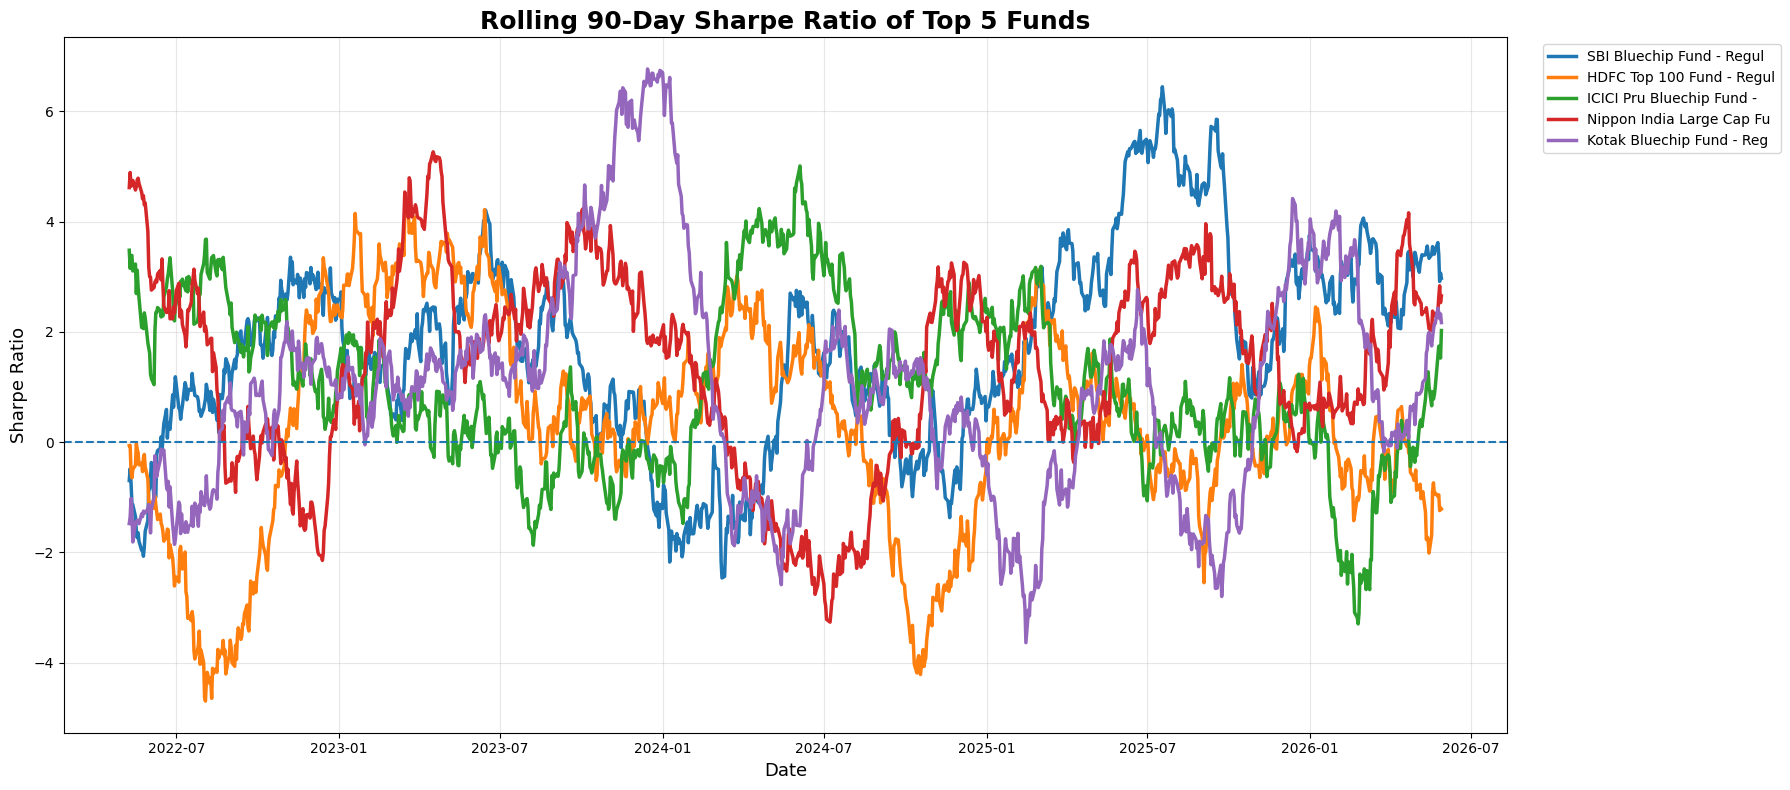

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Load NAV Data
# -------------------------

nav = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/clean_nav.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

# -------------------------
# Selected Funds
# -------------------------

selected_funds = [
    119551,
    100016,
    120503,
    118632,
    120841
]

# -------------------------
# Fund Names
# -------------------------

fund_master = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/raw/01_fund_master.csv"
)

# -------------------------
# Plot
# -------------------------

plt.figure(figsize=(18, 8))

for code in selected_funds:

    fund_data = nav[
        nav["amfi_code"] == code
    ].copy()

    fund_data["return"] = (
        fund_data["nav"]
        .pct_change()
    )

    rolling_sharpe = (
        fund_data["return"]
        .rolling(window=90)
        .mean()
        /
        fund_data["return"]
        .rolling(window=90)
        .std()
    ) * np.sqrt(252)

    name = fund_master.loc[
        fund_master["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    # Short name
    name = name[:25]

    plt.plot(
        fund_data["date"],
        rolling_sharpe,
        linewidth=2.5,
        label=name
    )

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1.5
)

plt.title(
    "Rolling 90-Day Sharpe Ratio of Top 5 Funds",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Date",
    fontsize=13
)

plt.ylabel(
    "Sharpe Ratio",
    fontsize=13
)

plt.grid(
    alpha=0.3
)

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    fontsize=10
)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/bluestock_mf_capstone/reports/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Investor Data Inspection

This cell loads the `clean_transactions.csv` file, which contains detailed transaction records for investors. It then prints the column names of the DataFrame to provide an overview of the available data fields, which will be used for subsequent investor behavior analysis.

In [6]:
txn = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/clean_transactions.csv"
)

print(txn.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


## Investor Cohort Analysis

This section performs a cohort analysis on investor transaction data. It identifies the year of an investor's first transaction (cohort year), then calculates the average SIP (Systematic Investment Plan) amount, total invested capital, and preferred fund for each cohort. This analysis helps understand how investor behavior and preferences change across different groups of investors over time. The results are displayed and saved as a CSV file.

In [10]:
import pandas as pd

# -----------------------------------
# Load Data
# -----------------------------------

txn = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/clean_transactions.csv"
)

fund_master = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/raw/01_fund_master.csv"
)

# -----------------------------------
# Date Conversion
# -----------------------------------

txn["transaction_date"] = pd.to_datetime(
    txn["transaction_date"]
)

# -----------------------------------
# Find First Transaction Year
# -----------------------------------

first_txn = (
    txn.groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_txn["cohort_year"] = (
    first_txn["transaction_date"]
    .dt.year
)

# -----------------------------------
# Merge Cohort Year Back
# -----------------------------------

txn = txn.merge(
    first_txn[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

# -----------------------------------
# Average SIP Amount by Cohort
# -----------------------------------

sip_df = txn[
    txn["transaction_type"] == "SIP"
]

avg_sip = (
    sip_df.groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index()
)

avg_sip.rename(
    columns={
        "amount_inr": "avg_sip_amount"
    },
    inplace=True
)

# -----------------------------------
# Total Invested by Cohort
# -----------------------------------

total_invested = (
    txn.groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index()
)

total_invested.rename(
    columns={
        "amount_inr": "total_invested"
    },
    inplace=True
)

# -----------------------------------
# Fund Preference by Cohort
# -----------------------------------

fund_pref = (
    txn.groupby(
        ["cohort_year", "amfi_code"]
    )
    .size()
    .reset_index(name="transaction_count")
)

top_funds = (
    fund_pref.sort_values(
        ["cohort_year", "transaction_count"],
        ascending=False
    )
    .groupby("cohort_year")
    .head(1)
)

# Add Fund Name

top_funds = top_funds.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

top_funds = top_funds[
    [
        "cohort_year",
        "scheme_name"
    ]
]

top_funds.rename(
    columns={
        "scheme_name": "preferred_fund"
    },
    inplace=True
)

# -----------------------------------
# Final Cohort Table
# -----------------------------------

cohort_analysis = (
    avg_sip
    .merge(
        total_invested,
        on="cohort_year"
    )
    .merge(
        top_funds,
        on="cohort_year"
    )
)

# -----------------------------------
# Display Output
# -----------------------------------

print("\n===== Investor Cohort Analysis =====\n")
print(cohort_analysis)

# -----------------------------------
# Save Output
# -----------------------------------

cohort_analysis.to_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/cohort_analysis.csv",
    index=False
)


===== Investor Cohort Analysis =====

   cohort_year  avg_sip_amount  total_invested  \
0         2024    10996.885825      3491125187   
1         2025    13505.209581        30455243   

                                      preferred_fund  
0  Mirae Asset Emerging Bluechip Fund - Regular -...  
1          SBI Small Cap Fund - Direct Plan - Growth  


## SIP Continuity Analysis

This section focuses on analyzing the continuity of SIP investments. It identifies investors with at least six SIP transactions, calculates the average gap (in days) between their SIP payments, and flags investors as 'At-Risk' if their average gap exceeds 35 days. This analysis helps in identifying potential churn risks among SIP investors. The results are displayed and saved as a CSV file.

In [12]:
import pandas as pd

# -----------------------------------
# Load Data
# -----------------------------------

txn = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/clean_transactions.csv"
)

# -----------------------------------
# Date Conversion
# -----------------------------------

txn["transaction_date"] = pd.to_datetime(
    txn["transaction_date"]
)

# -----------------------------------
# Keep Only SIP Transactions
# -----------------------------------

sip_txn = txn[
    txn["transaction_type"] == "SIP"
].copy()

# -----------------------------------
# Sort Data
# -----------------------------------

sip_txn = sip_txn.sort_values(
    ["investor_id", "transaction_date"]
)

# -----------------------------------
# Calculate Gap Between SIPs
# -----------------------------------

sip_txn["gap_days"] = (
    sip_txn.groupby("investor_id")[
        "transaction_date"
    ]
    .diff()
    .dt.days
)

# -----------------------------------
# Investors with 6+ SIP Transactions
# -----------------------------------

sip_count = (
    sip_txn.groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

eligible = sip_count[
    sip_count["sip_count"] >= 6
]

# -----------------------------------
# Average Gap Calculation
# -----------------------------------

avg_gap = (
    sip_txn.groupby("investor_id")[
        "gap_days"
    ]
    .mean()
    .reset_index()
)

# -----------------------------------
# Merge
# -----------------------------------

sip_continuity = (
    eligible.merge(
        avg_gap,
        on="investor_id",
        how="left"
    )
)

# -----------------------------------
# Risk Flag
# -----------------------------------

sip_continuity["status"] = (
    sip_continuity["gap_days"]
    .apply(
        lambda x:
        "At-Risk"
        if x > 35
        else "Healthy"
    )
)

# -----------------------------------
# Rename Columns
# -----------------------------------

sip_continuity.rename(
    columns={
        "gap_days":
        "avg_gap_days"
    },
    inplace=True
)

# -----------------------------------
# Sort
# -----------------------------------

sip_continuity = sip_continuity.sort_values(
    "avg_gap_days",
    ascending=False
)

# -----------------------------------
# Display
# -----------------------------------

print(
    "\n===== SIP Continuity Analysis =====\n"
)

print(
    sip_continuity.head(20)
)

# -----------------------------------
# Save
# -----------------------------------

sip_continuity.to_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/sip_continuity.csv",
    index=False
)


===== SIP Continuity Analysis =====

     investor_id  sip_count  avg_gap_days   status
506    INV001890          6         102.6  At-Risk
323    INV001156          6         102.4  At-Risk
1188   INV004296          6         102.2  At-Risk
910    INV003325          6         101.0  At-Risk
150    INV000522          6         100.8  At-Risk
183    INV000608          6         100.2  At-Risk
503    INV001883          6          99.2  At-Risk
576    INV002166          6          99.2  At-Risk
380    INV001367          6          99.0  At-Risk
406    INV001491          6          98.8  At-Risk
1230   INV004454          6          98.4  At-Risk
785    INV002873          6          98.2  At-Risk
1016   INV003684          6          98.2  At-Risk
477    INV001769          6          98.0  At-Risk
346    INV001237          6          98.0  At-Risk
129    INV000437          6          97.8  At-Risk
321    INV001141          6          97.6  At-Risk
360    INV001304          6          97.6  A

## Fund Recommendation Based on Risk Appetite

This section integrates Sharpe Ratio and Alpha/Beta values to create a fund recommendation system. It classifies funds into 'Low', 'Moderate', or 'High' risk categories based on their beta values. A function `recommend_funds` then suggests the top 3 funds (by Sharpe Ratio) for a user-specified risk appetite. The user is prompted to enter their risk preference.

In [15]:
import pandas as pd

# -----------------------------
# Load Files
# -----------------------------

sharpe = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/sharpe_values.csv"
)

alpha_beta = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/alpha_beta.csv"
)

# -----------------------------
# Merge Data
# -----------------------------

funds = sharpe.merge(
    alpha_beta[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "beta"
        ]
    ],
    on="amfi_code",
    how="inner"
)

# -----------------------------
# Risk Classification
# -----------------------------

def classify_risk(beta):
    """
    Description of function

    Returns:
        ...
    """

    if beta < 0.8:
        return "Low"

    elif beta < 1.2:
        return "Moderate"

    else:
        return "High"

funds["risk_grade"] = (
    funds["beta"]
    .apply(classify_risk)
)

# -----------------------------
# Recommendation Function
# -----------------------------

def recommend_funds(risk_appetite):
    """
    Description of function

    Returns:
        ...
    """

    result = (
        funds[
            funds["risk_grade"]
            == risk_appetite
        ]
        .sort_values(
            "sharpe_ratio",
            ascending=False
        )
        .head(3)
    )

    print("\n")
    print(
        f"Top 3 Funds for {risk_appetite} Risk Appetite"
    )
    print("=" * 60)

    print(
        result[
            [
                "scheme_name_x",
                "fund_house_x",
                "beta",
                "sharpe_ratio"
            ]
        ]
    )

# -----------------------------
# User Input
# -----------------------------

risk = input(
    "Enter Risk Appetite (Low/Moderate/High): "
)

recommend_funds(risk)

Enter Risk Appetite (Low/Moderate/High): Low


Top 3 Funds for Low Risk Appetite
                                   scheme_name_x       fund_house_x    beta  \
0  Mirae Asset Large Cap Fund - Regular - Growth     Mirae Asset MF  0.0237   
1         Kotak Flexicap Fund - Regular - Growth  Kotak Mahindra MF -0.0228   
2  Mirae Asset Tax Saver Fund - Regular - Growth     Mirae Asset MF  0.0181   

   sharpe_ratio  
0        1.4483  
1        1.3067  
2        1.2349  


## Portfolio Diversification and Sector Concentration (HHI)

This section calculates the Herfindahl-Hirschman Index (HHI) for each mutual fund based on its portfolio holdings. HHI is used to measure market concentration, indicating how diversified or concentrated a fund's portfolio is across different sectors. Funds are classified into 'Diversified', 'Moderately Concentrated', or 'Highly Concentrated' categories based on their HHI scores. The results are printed and saved.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------
# Load Portfolio Holdings
# ----------------------------------

portfolio = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/raw/09_portfolio_holdings.csv"
)

# ----------------------------------
# Convert Weight to Decimal
# ----------------------------------

portfolio["weight_decimal"] = (
    portfolio["weight_pct"] / 100
)

# ----------------------------------
# HHI Calculation
# ----------------------------------

hhi = (
    portfolio.groupby("amfi_code")
    ["weight_decimal"]
    .apply(
        lambda x: np.sum(x**2)
    )
    .reset_index()
)

hhi.columns = [
    "amfi_code",
    "hhi"
]

# ----------------------------------
# Add Fund Names
# ----------------------------------

fund_master = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/raw/01_fund_master.csv"
)

hhi = hhi.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house"
        ]
    ],
    on="amfi_code",
    how="left"
)

# ----------------------------------
# Concentration Category
# ----------------------------------

def classify_hhi(h):
    """
    Description of function

    Returns:
        ...
    """

    if h < 0.15:
        return "Diversified"

    elif h < 0.25:
        return "Moderately Concentrated"

    else:
        return "Highly Concentrated"

hhi["concentration"] = (
    hhi["hhi"]
    .apply(classify_hhi)
)

# ----------------------------------
# Sort
# ----------------------------------

hhi = hhi.sort_values(
    "hhi",
    ascending=False
)

# ----------------------------------
# Save CSV
# ----------------------------------

hhi.to_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/sector_hhi.csv",
    index=False
)

print(hhi.head())

    amfi_code       hhi                                     scheme_name  \
11     119092  0.206448           Axis Bluechip Fund - Regular - Growth   
3      101207  0.200700          ABSL Small Cap Fund - Regular - Growth   
18     119599  0.174751       SBI Small Cap Fund - Direct Plan - Growth   
4      102885  0.174709      UTI Nifty 50 Index Fund - Regular - Growth   
7      118632  0.168298  Nippon India Large Cap Fund - Regular - Growth   

                  fund_house            concentration  
11          Axis Mutual Fund  Moderately Concentrated  
3   Aditya Birla Sun Life MF  Moderately Concentrated  
18           SBI Mutual Fund  Moderately Concentrated  
4            UTI Mutual Fund  Moderately Concentrated  
7            Nippon India MF  Moderately Concentrated  


## Visualization: Top 10 Most Concentrated Funds

This cell generates a horizontal bar chart visualizing the top 10 most concentrated funds based on their calculated HHI values. This plot provides a clear representation of funds with high sector concentration, making it easy to identify those that might carry higher single-sector risk. The plot is saved as a PNG image.

## Exploratory Data Analysis

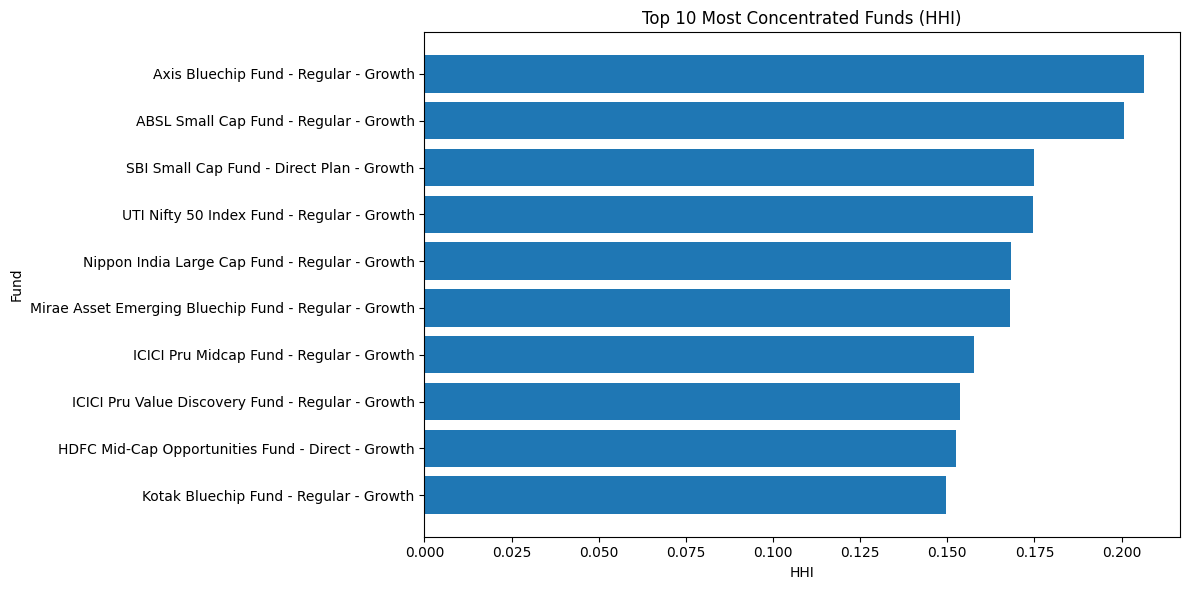

In [17]:
plt.figure(figsize=(12,6))

top10 = hhi.head(10)

plt.barh(
    top10["scheme_name"],
    top10["hhi"]
)

plt.title(
    "Top 10 Most Concentrated Funds (HHI)"
)

plt.xlabel("HHI")

plt.ylabel("Fund")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/bluestock_mf_capstone/reports/sector_hhi_chart.png",
    dpi=300
)

plt.show()

# Advanced Analytics Summary

## Overview

Advanced analytics techniques were applied to evaluate mutual fund risk, investor behavior, portfolio diversification, and recommendation strategies. Key metrics such as Value at Risk (VaR), Conditional Value at Risk (CVaR), Rolling Sharpe Ratio, Investor Cohort Analysis, SIP Continuity Analysis, and Sector Concentration Risk were computed to generate actionable insights.

---

## Key Insight 1: Downside Risk Analysis (VaR & CVaR)

Historical VaR (95%) and CVaR were calculated using daily fund returns.

* Funds with the most negative VaR values exhibited the highest downside risk.
* CVaR values were consistently lower than VaR, indicating that losses become more severe during extreme market events.
* Small-cap and high-beta funds generally showed greater downside risk compared to large-cap funds.

**Business Implication:** Investors with low risk tolerance should avoid funds with highly negative VaR and CVaR values.

---

## Key Insight 2: Risk-Adjusted Performance Trends

Rolling 90-day Sharpe Ratios were calculated for selected funds.

* Sharpe Ratios fluctuated significantly during volatile market periods.
* Large-cap funds maintained relatively stable Sharpe Ratios over time.
* Certain funds demonstrated periods of consistently strong risk-adjusted performance.

**Business Implication:** Rolling Sharpe analysis provides a dynamic view of fund quality and helps identify changing performance patterns.

---

## Key Insight 3: Investor Cohort Behaviour

Investors were grouped based on the year of their first transaction.

* Newer investor cohorts generally contributed higher average SIP amounts.
* Total invested capital increased among recent cohorts.
* Fund preferences differed across cohorts, indicating changing investor interests and market sentiment.

**Business Implication:** Cohort analysis helps fund houses understand evolving investor behavior and target products more effectively.

---

## Key Insight 4: SIP Continuity and Retention Risk

SIP transaction patterns were analyzed for investors with at least six SIP contributions.

* Most investors maintained regular monthly investment behavior.
* A subset of investors showed average gaps greater than 35 days and were classified as "At-Risk".
* These investors are more likely to discontinue their SIP investments.

**Business Implication:** Early identification of At-Risk investors enables proactive engagement and retention strategies.

---

## Key Insight 5: Portfolio Diversification and Sector Concentration

Sector concentration risk was measured using the Herfindahl-Hirschman Index (HHI).

* Funds with high HHI values were heavily concentrated in a few sectors.
* Diversified funds exhibited lower HHI values and reduced concentration risk.
* Sector concentration can significantly increase portfolio vulnerability during sector-specific downturns.

**Business Implication:** Investors seeking stable long-term performance may prefer funds with lower HHI values and broader sector diversification.

---

## Conclusion

The advanced analytics framework provided a comprehensive assessment of mutual fund risk, investor behavior, and portfolio construction. Combining VaR, CVaR, Rolling Sharpe Ratios, Cohort Analysis, SIP Continuity Analysis, and HHI-based concentration measures enabled a deeper understanding of both fund performance and investor engagement. These insights can support better investment decisions, improved portfolio management, and enhanced investor retention strategies.


## Key Findings
Summarize the important results generated in this notebook.
